# XGBoost：葡萄酒类别多分类项目

**适合人群：** 已完成 Python 入门和至少一个基础分类项目，希望学习梯度提升树的初学者。

**项目目标：** 根据葡萄酒的 13 个化学测量特征，预测样本属于 3 个类别中的哪一类。

**完成标准：** 能解释 XGBoost 如何逐步改进错误，完成基准比较、交叉验证、参数搜索、多分类评估、特征解释、预测和模型保存。

## 项目路线

1. 理解 XGBoost 的核心思想
2. 加载并检查葡萄酒数据
3. 探索类别和特征
4. 隔离测试集
5. 建立多数类基准
6. 训练第一个 XGBoost 模型
7. 使用随机搜索调整参数
8. 在测试集上最终评估
9. 解释、预测并保存模型

## XGBoost 在做什么？

XGBoost 会依次建立多棵较小的决策树。每棵新树重点修正前面模型的错误，最后把所有树的结果组合起来。

本项目关注这些参数：

- `n_estimators`：树的数量。
- `learning_rate`：每棵新树对最终结果的贡献。
- `max_depth`：每棵树的最大深度。
- `subsample`：每棵树使用的样本比例。
- `colsample_bytree`：每棵树使用的特征比例。

较小学习率通常需要更多树；树太深或树太多可能过拟合。

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import xgboost as xgb
from sklearn.datasets import load_wine
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

print("pandas 版本：", pd.__version__)
print("scikit-learn 版本：", sklearn.__version__)
print("xgboost 版本：", xgb.__version__)

pandas 版本： 1.5.3
scikit-learn 版本： 1.2.2
xgboost 版本： 3.2.0


## 1. 加载数据

葡萄酒数据集随 `scikit-learn` 提供，不需要联网下载。每行是一份样本，特征包括酒精、苹果酸、镁和颜色强度等化学测量值。

In [2]:
dataset = load_wine(as_frame=True)
X = dataset.data.copy()
y = dataset.target.copy()
class_names = list(dataset.target_names)

df = X.copy()
df["wine_class"] = y.map(dict(enumerate(class_names)))

print(f"样本数：{X.shape[0]}")
print(f"特征数：{X.shape[1]}")
print("类别：", class_names)
df.head()

样本数：178
特征数：13
类别： ['class_0', 'class_1', 'class_2']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## 2. 检查数据

检查缺失值、重复记录、数据类型和类别分布。

In [3]:
quality_check = pd.Series({
    "缺失值总数": int(X.isna().sum().sum()),
    "重复行数量": int(X.duplicated().sum()),
    "数值特征数量": int(X.select_dtypes(include=np.number).shape[1]),
    "类别数量": int(y.nunique()),
}, name="检查结果")
quality_check.to_frame()

,检查结果
缺失值总数,0
重复行数量,0
数值特征数量,13
类别数量,3


,样本数
class_0,59
class_1,71
class_2,48


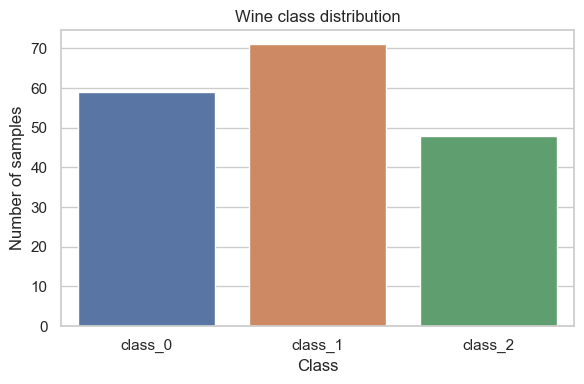

In [4]:
class_counts = df["wine_class"].value_counts().sort_index()
display(class_counts.to_frame(name="样本数"))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="wine_class", hue="wine_class", legend=False)
plt.title("Wine class distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.tight_layout()
plt.show()

三个类别的样本数并不完全相等。因此除了准确率，还使用宏平均 F1；它会让每个类别获得相同权重。

## 3. 探索特征

先比较几个代表性特征在不同类别中的中位数，再用散点图观察两个特征能否分开类别。

In [5]:
selected_features = [
    "alcohol",
    "malic_acid",
    "flavanoids",
    "color_intensity",
    "proline",
]
df.groupby("wine_class")[selected_features].median().round(2)

,alcohol,malic_acid,flavanoids,color_intensity,proline
wine_class,,,,,
class_0,13.75,1.77,2.98,5.40,1095.0
class_1,12.29,1.61,2.03,2.90,495.0
class_2,13.16,3.26,0.68,7.55,627.5


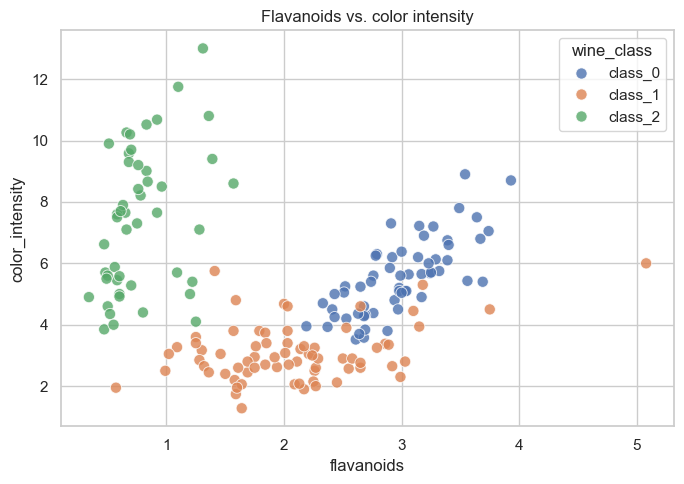

In [6]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="flavanoids",
    y="color_intensity",
    hue="wine_class",
    s=65,
    alpha=0.8,
)
plt.title("Flavanoids vs. color intensity")
plt.tight_layout()
plt.show()

部分类别在二维图中仍有重叠。XGBoost 会利用全部 13 个特征，并通过多棵树组合出非线性规则。

## 4. 隔离测试集

测试集占 20%，只用于参数确定后的最终评估。`stratify=y` 保持各类别比例。

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("训练集：", X_train.shape)
print("测试集：", X_test.shape)
print("训练集类别数量：", y_train.value_counts().sort_index().to_dict())
print("测试集类别数量：", y_test.value_counts().sort_index().to_dict())

训练集： (142, 13)
测试集： (36, 13)
训练集类别数量： {0: 47, 1: 57, 2: 38}
测试集类别数量： {0: 12, 1: 14, 2: 10}


## 5. 多数类基准

基准模型总是预测训练集中最多的类别。XGBoost 必须明显超过它。所有比较都只在训练集的 5 折交叉验证中进行。

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline = DummyClassifier(strategy="most_frequent")

baseline_scores = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
)

print(f"基准准确率：{baseline_scores['test_accuracy'].mean():.2%}")
print(f"基准宏平均 F1：{baseline_scores['test_f1_macro'].mean():.2%}")

基准准确率：40.12%
基准宏平均 F1：19.09%


## 6. 第一个 XGBoost 模型

树模型根据阈值切分特征，通常不需要标准化。这里使用一组合理的初始参数，并在训练集上进行交叉验证。

In [9]:
initial_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    n_estimators=150,
    learning_rate=0.08,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

initial_scores = cross_validate(
    initial_model,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "f1_macro": "f1_macro",
        "neg_log_loss": "neg_log_loss",
    },
    n_jobs=1,
)

print(f"XGBoost 交叉验证准确率：{initial_scores['test_accuracy'].mean():.2%}")
print(f"XGBoost 交叉验证宏平均 F1：{initial_scores['test_f1_macro'].mean():.2%}")
print(f"XGBoost 交叉验证 Log Loss：{-initial_scores['test_neg_log_loss'].mean():.3f}")

XGBoost 交叉验证准确率：97.91%
XGBoost 交叉验证宏平均 F1：97.89%
XGBoost 交叉验证 Log Loss：0.104


## 7. 随机搜索参数

参数组合很多，全部穷举会浪费时间。随机搜索从候选范围抽取 20 组组合，用训练集交叉验证的宏平均 F1 选择最佳模型。

In [10]:
search_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

parameter_space = {
    "n_estimators": [100, 150, 250, 350],
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.75, 0.9, 1.0],
    "colsample_bytree": [0.75, 0.9, 1.0],
}

random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=parameter_space,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=False,
)
random_search.fit(X_train, y_train)
print("参数搜索完成")

参数搜索完成


In [11]:
search_results = (
    pd.DataFrame(random_search.cv_results_)
    .sort_values("rank_test_score")
    [["params", "mean_test_score", "std_test_score", "rank_test_score"]]
    .head(5)
)
search_results

,params,mean_test_score,std_test_score,rank_test_score
9,"{'subsample': 1.0, 'n_estimators': 250, 'min_c...",0.972779,0.039892,1
15,"{'subsample': 0.9, 'n_estimators': 350, 'min_c...",0.972779,0.039892,1
2,"{'subsample': 0.9, 'n_estimators': 150, 'min_c...",0.966095,0.037499,3
3,"{'subsample': 0.9, 'n_estimators': 350, 'min_c...",0.966095,0.037499,3
13,"{'subsample': 1.0, 'n_estimators': 150, 'min_c...",0.966095,0.037499,3


In [12]:
initial_cv_f1 = initial_scores["test_f1_macro"].mean()
search_cv_f1 = random_search.best_score_

if initial_cv_f1 >= search_cv_f1:
    best_model = initial_model.fit(X_train, y_train)
    selected_model_name = "初始模型"
    selected_cv_f1 = initial_cv_f1
else:
    best_model = random_search.best_estimator_
    selected_model_name = "随机搜索模型"
    selected_cv_f1 = search_cv_f1

print("随机搜索最佳参数：")
for name, value in random_search.best_params_.items():
    print(f"  {name}: {value}")
print(f"随机搜索最佳宏平均 F1：{search_cv_f1:.2%}")
print(f"最终选择：{selected_model_name}（宏平均 F1：{selected_cv_f1:.2%}）")

随机搜索最佳参数：
  subsample: 1.0
  n_estimators: 250
  min_child_weight: 1
  max_depth: 3
  learning_rate: 0.05
  colsample_bytree: 0.9
随机搜索最佳宏平均 F1：97.28%
最终选择：初始模型（宏平均 F1：97.89%）


**调参结果：** 随机搜索不一定超过合理的初始参数。这里用训练集交叉验证结果在二者中选择更好的模型，再进行最终测试。

## 8. 测试集最终评估

参数已经确定，现在只使用一次测试集。宏平均指标让每个类别获得相同权重，Log Loss 还会检查预测概率是否合理。

In [13]:
y_pred = best_model.predict(X_test)
y_probability = best_model.predict_proba(X_test)

final_metrics = pd.Series({
    "准确率": accuracy_score(y_test, y_pred),
    "宏平均精确率": precision_score(y_test, y_pred, average="macro"),
    "宏平均召回率": recall_score(y_test, y_pred, average="macro"),
    "宏平均 F1": f1_score(y_test, y_pred, average="macro"),
    "多分类 ROC-AUC": roc_auc_score(
        y_test, y_probability, multi_class="ovr", average="macro"
    ),
}, name="测试集结果")

display(final_metrics.to_frame().style.format("{:.2%}"))
print(f"Log Loss：{log_loss(y_test, y_probability):.3f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))

,测试集结果
准确率,100.00%
宏平均精确率,100.00%
宏平均召回率,100.00%
宏平均 F1,100.00%
多分类 ROC-AUC,100.00%


Log Loss：0.030

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



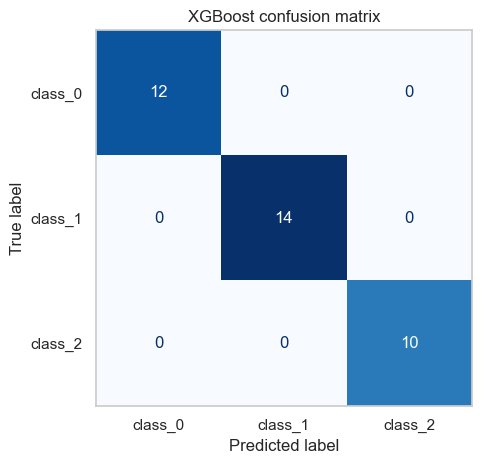

In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=class_names,
    cmap="Blues",
    colorbar=False,
)
plt.title("XGBoost confusion matrix")
plt.grid(False)
plt.tight_layout()
plt.show()

## 9. 解释模型

使用置换重要性：随机打乱一个特征，观察宏平均 F1 下降多少。下降越多，说明模型越依赖该特征。重要性表示模型依赖关系，不等于因果关系。

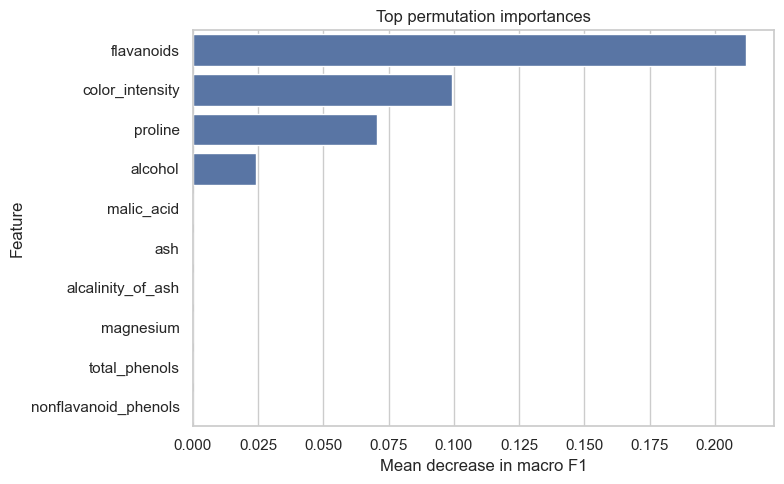

In [15]:
importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_table = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": importance.importances_mean,
    })
    .sort_values("importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_table, x="importance", y="feature")
plt.title("Top permutation importances")
plt.xlabel("Mean decrease in macro F1")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. 预测一个新样本

下面取一条测试样本演示多分类预测和各类别概率。

In [16]:
sample = X_test.iloc[[0]]
actual_class = class_names[int(y_test.iloc[0])]
predicted_index = int(best_model.predict(sample)[0])
predicted_class = class_names[predicted_index]
sample_probabilities = best_model.predict_proba(sample)[0]

print("真实类别：", actual_class)
print("预测类别：", predicted_class)
pd.Series(
    sample_probabilities,
    index=class_names,
    name="预测概率",
).to_frame().round(3)

真实类别： class_0
预测类别： class_0


,预测概率
class_0,0.995
class_1,0.003
class_2,0.002


## 11. 保存模型

XGBoost 原生 JSON 格式适合长期保存模型结构；另外保存特征名和类别名，确保未来输入顺序正确。

In [17]:
model_dir = Path("models")
model_dir.mkdir(exist_ok=True)
model_path = model_dir / "xgboost_wine_model.json"
metadata_path = model_dir / "xgboost_wine_metadata.joblib"

best_model.save_model(model_path)
joblib.dump({
    "feature_names": list(X.columns),
    "class_names": class_names,
    "xgboost_version": xgb.__version__,
}, metadata_path)

print("模型已保存到：", model_path.resolve())
print("元数据已保存到：", metadata_path.resolve())

模型已保存到： C:\Users\86157\Documents\学习系统\output\jupyter-notebook\xgboost-wine-project\models\xgboost_wine_model.json
元数据已保存到： C:\Users\86157\Documents\学习系统\output\jupyter-notebook\xgboost-wine-project\models\xgboost_wine_metadata.joblib


## 练习：学习率与树数量

分别尝试以下组合，并比较训练集交叉验证的宏平均 F1：

- `learning_rate=0.2, n_estimators=80`
- `learning_rate=0.05, n_estimators=300`

In [18]:
# 练习答案框架：修改这两个值并重新运行
exercise_learning_rate = 0.2
exercise_n_estimators = 80

exercise_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    learning_rate=exercise_learning_rate,
    n_estimators=exercise_n_estimators,
    max_depth=3,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
exercise_result = cross_validate(
    exercise_model, X_train, y_train, cv=cv, scoring="f1_macro"
)["test_score"]
print(f"平均宏 F1：{exercise_result.mean():.2%}")

平均宏 F1：96.61%


## 常见错误与改进方向

- **用测试集调参：** 会让结果过于乐观。这里所有搜索都只使用训练集。
- **树太深：** 容易记住小数据集中的噪声。应通过交叉验证控制 `max_depth`。
- **学习率和树数量分开调整：** 两者需要配合；学习率越小通常需要更多树。
- **只看准确率：** 多分类应同时检查宏平均 F1 和混淆矩阵。
- **不必要的标准化：** 树模型按阈值切分，通常不需要像 SVM 那样缩放。

可选扩展：加入早停法、与随机森林比较，或在更大的表格数据集上测试训练速度。

## 项目结论

本项目完成了一个可重复运行的 XGBoost 多分类流程：数据检查、探索、测试集隔离、基准模型、交叉验证、随机参数搜索、最终评估、特征解释、单样本预测和模型保存。

提交项目时应能说明：XGBoost 如何逐步修正错误，学习率和树数量为什么需要配合，为什么树模型通常不需要标准化，以及为什么参数搜索不能使用测试集。